In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

data_path = "../data/SN_d_tot_V2.0.csv"
column_names = ["year","month","day","decimal_date","sunspots","std_dev","n_observations","definitive"]
df = pd.read_csv(data_path, sep=";", header=None, names=column_names)

df_clean = df[df["sunspots"] != -1].reset_index(drop=True)
series = df_clean["sunspots"].values

In [2]:
split_idx = int(len(series) * 0.8)
train_data = series[:split_idx]
test_data = series[split_idx:]

In [3]:
print(len(train_data))
print(len(test_data))

58300
14575


In [4]:
# Min-Max-Normalisation

train_min = train_data.min()
train_max = train_data.max()

train_scaled = (train_data - train_min) / (train_max - train_min)

print(train_scaled.min())
print(train_scaled.max())

0.0
1.0


In [5]:
test_scaled = (test_data - train_min) / (train_max - train_min)

print(test_scaled.min())
print(test_scaled.max())

0.0
0.7765151515151515


In [6]:
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

In [7]:
window_size = 30
X_train, y_train = create_windows(train_scaled, window_size)
X_test, y_test = create_windows(test_scaled, window_size)

print(X_train.shape, y_train.shape)

(58270, 30) (58270,)


In [8]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

In [9]:
print(X_train_t.shape, y_train_t.shape)
print(X_test_t.shape, y_test_t.shape)

torch.Size([58270, 30, 1]) torch.Size([58270, 1])
torch.Size([14545, 30, 1]) torch.Size([14545, 1])


In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for batch_X, batch_y in train_loader:
    print(batch_X.shape, batch_y.shape)
    break

torch.Size([64, 30, 1]) torch.Size([64, 1])


In [11]:
import torch.nn as nn

class SunspotLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1 )

    def forward(self,x):
        out, _ = self.lstm(x)
        out = out[:, -1 , :]
        out = self.fc(out)
        return out

In [12]:
model = SunspotLSTM()

for batch_X, batch_y in train_loader:
    test_output = model(batch_X)
    print(test_output.shape)
    break

torch.Size([64, 1])


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [14]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)   # NEW
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

Epoch 1/10, Loss: 0.003900
Epoch 2/10, Loss: 0.002056
Epoch 3/10, Loss: 0.002005
Epoch 4/10, Loss: 0.002011
Epoch 5/10, Loss: 0.001999
Epoch 6/10, Loss: 0.001981
Epoch 7/10, Loss: 0.001986
Epoch 8/10, Loss: 0.001977
Epoch 9/10, Loss: 0.001982
Epoch 10/10, Loss: 0.001974


In [15]:
model.eval
all_predictions = []
all_actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        all_predictions.append(predictions)
        all_actuals.append(batch_y)

all_predictions = torch.cat(all_predictions).numpy()
all_actuals = torch.cat(all_actuals).numpy()

In [16]:
import numpy as np

predictions_real = all_predictions * (train_max - train_min) + train_min
actuals_real = all_actuals * (train_max - train_min) + train_min

rmse = np.sqrt(np.mean((predictions_real - actuals_real) ** 2))
print(f"RMSE: {rmse:.2f} Sonnenflecken")

RMSE: 14.78 Sonnenflecken


In [17]:
# Error relative to (max - min ) with test_data
spannweite = actuals_real.max() - actuals_real.min()
nrmse_range = rmse / spannweite * 100

print(f"NRMSE: {nrmse_range:.1f} %")

NRMSE: 3.6 %


In [26]:
naive_pred = actuals[1:]      # "Vorhersage" = der jeweils vorherige echte Wert
naive_true = actuals[:-1]
naive_rmse = np.sqrt(np.mean((naive_pred - naive_true) ** 2))
print(f"Naive baseline RMSE: {naive_rmse:.2f}  |  LSTM RMSE: 15.30")

Naive baseline RMSE: 15.12  |  LSTM RMSE: 15.30


In [18]:
torch.save(model.state_dict(), "../models/sunspot_lstm.pth")

## PLOTS

In [19]:
actuals = actuals_real.flatten()
preds = predictions_real.flatten()
residuals = preds - actuals

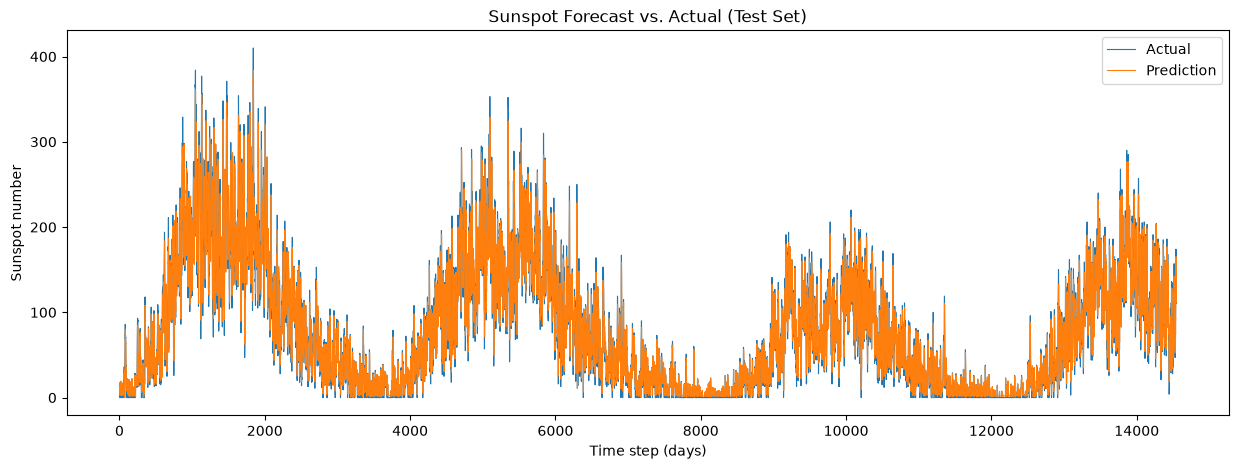

In [20]:
plt.figure(figsize=(15, 5))
plt.plot(actuals, label="Actual", linewidth=0.8)
plt.plot(preds, label="Prediction", linewidth=0.8)
plt.title("Sunspot Forecast vs. Actual (Test Set)")
plt.xlabel("Time step (days)")
plt.ylabel("Sunspot number")
plt.legend()
plt.savefig("../figures/01_forecast_full.png", dpi=150, bbox_inches="tight")
plt.show()

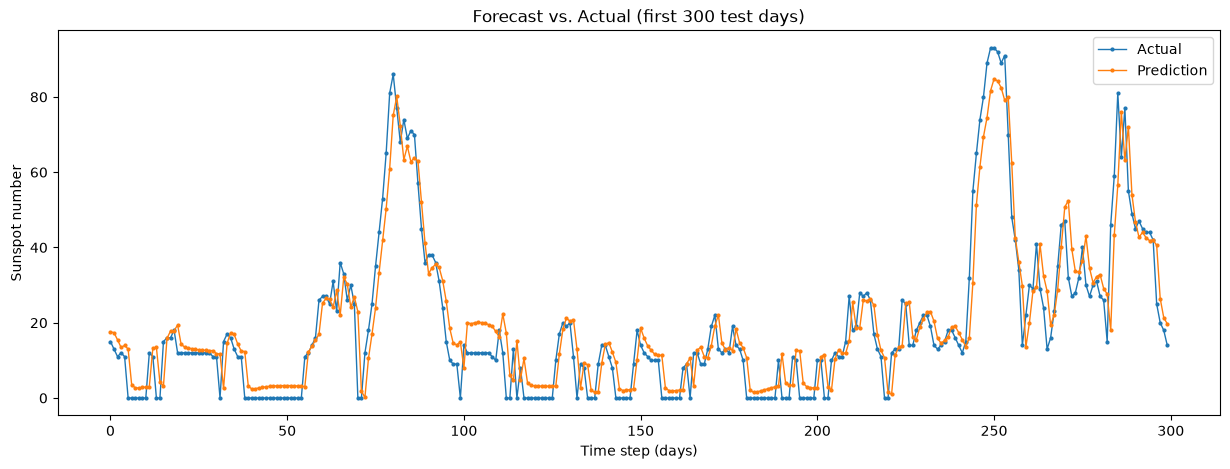

In [21]:
n = 300
plt.figure(figsize=(15, 5))
plt.plot(actuals[:n], label="Actual", marker="o", markersize=2, linewidth=1)
plt.plot(preds[:n], label="Prediction", marker="o", markersize=2, linewidth=1)
plt.title(f"Forecast vs. Actual (first {n} test days)")
plt.xlabel("Time step (days)")
plt.ylabel("Sunspot number")
plt.legend()
plt.savefig("../figures/02_forecast_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

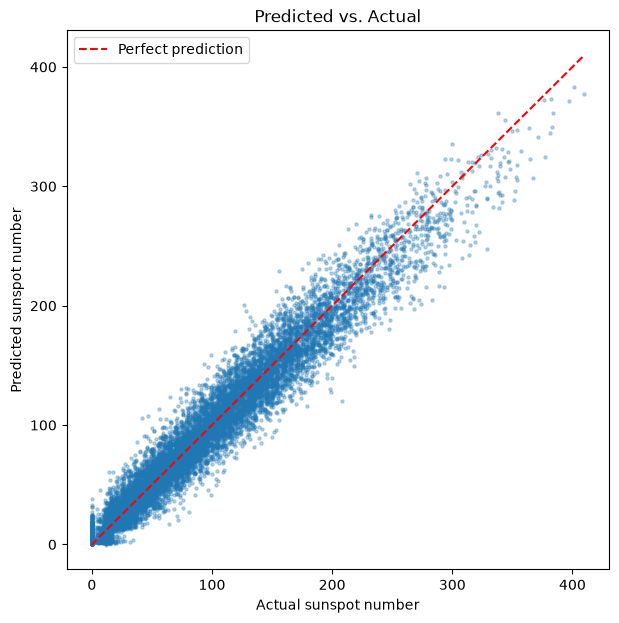

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(actuals, preds, s=5, alpha=0.3)
lims = [min(actuals.min(), preds.min()), max(actuals.max(), preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.title("Predicted vs. Actual")
plt.xlabel("Actual sunspot number")
plt.ylabel("Predicted sunspot number")
plt.legend()
plt.savefig("../figures/03_scatter_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

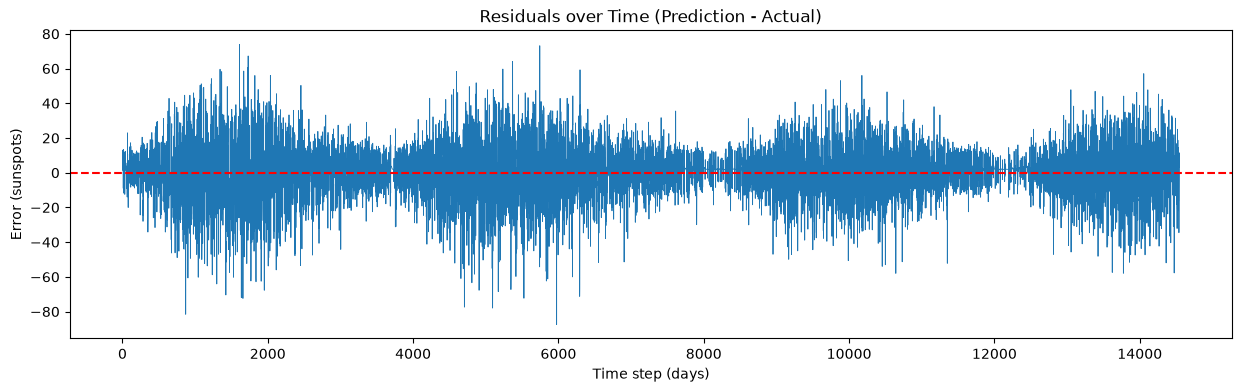

In [23]:
plt.figure(figsize=(15, 4))
plt.plot(residuals, linewidth=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals over Time (Prediction - Actual)")
plt.xlabel("Time step (days)")
plt.ylabel("Error (sunspots)")
plt.savefig("../figures/04_residuals_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

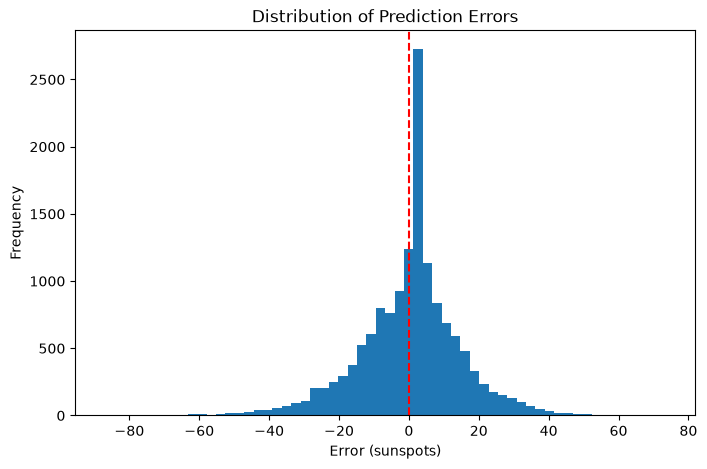

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=60)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (sunspots)")
plt.ylabel("Frequency")
plt.savefig("../figures/05_residuals_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

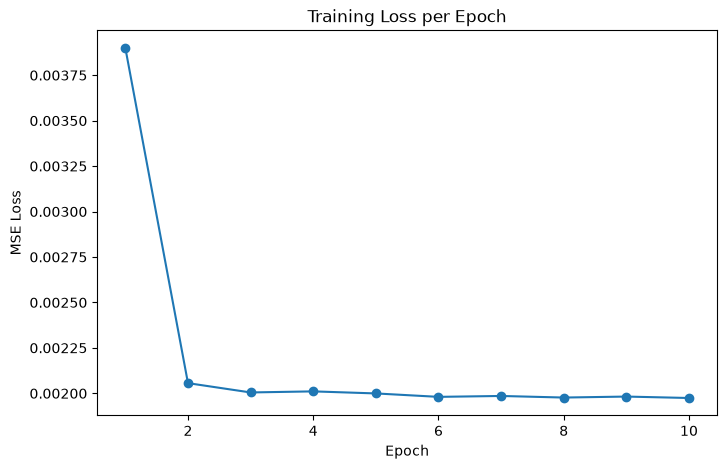

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.savefig("../figures/06_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()